In [ ]:
# Downloading the input file

import os, gdown
file_path = "./eng-fra.txt"

if not os.path.exists(file_path):
    file_id = "1iTRNRMrAuEUpQAuLdKZuYXY4JCQ3O08S"

    gdown.download(
        url=f"https://drive.google.com/uc?id={file_id}",
        output=file_path,
        quiet= True
    )
else:
    print("File is already ready")

## Transformer Architecture Implementation

In this notebook, I'm going to build the standard Encoder-Decoder Transformer architecture. The goal of this notebook is to get hands-on experience with building and training the Transformer architecture.

For this task, I picked a small English-to-French translation dataset from Kaggle.

**Task:** Machine Translation

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "./eng-fra.txt", sep="\t", header=None, usecols=[0, 1], names=["english", "french"]
)

df

,english,french
0,Go.,Va !
1,Go.,Marche.
2,Go.,En route !
3,Go.,Bouge !
4,Hi.,Salut !
...,...,...
239184,Death is something that we're often discourage...,La mort est une chose qu'on nous décourage sou...
239185,Since there are usually multiple websites on a...,Puisqu'il y a de multiples sites web sur chaqu...
239186,If someone who doesn't know your background sa...,Si quelqu'un qui ne connaît pas vos antécédent...
239187,It may be impossible to get a completely error...,Il est peut-être impossible d'obtenir un Corpu...


## Tokenization & Vocabulary

In [ ]:
english_vocab = {"<pad>": 0, "<eos>": 1}
french_vocab = {"<pad>": 0, "<bos>": 1, "<eos>": 2}


def word_tokenize(text):
    PUNCTUATION_TO_STRIP = '.,!?"()[]{}<>:;/=_+*&^%$#@`~'

    dirty_tokens = text.lower().split()
    clean_tokens = []

    for token in dirty_tokens:
        clean_token = token.strip(PUNCTUATION_TO_STRIP)
        if clean_token:
            clean_tokens.append(clean_token)

    return clean_tokens


def forming_vocab(text, lang):
    tokenize_text = word_tokenize(text)

    if lang == "eng":
        for word in tokenize_text:
            if word not in english_vocab:
                english_vocab[word] = len(english_vocab)

    if lang == "fre":
        for word in tokenize_text:
            if word not in french_vocab:
                french_vocab[word] = len(french_vocab)


def decode_seq(input_seq: list):
    for idx in input_seq:
        print(rev_french_vocab[idx], end=" ")

    print()


# applying
df["english"].apply(lambda text: forming_vocab(text, "eng"))
df["french"].apply(lambda text: forming_vocab(text, "fre"))


rev_english_vocab = {val: key for key, val in english_vocab.items()}
rev_french_vocab = {val: key for key, val in french_vocab.items()}

print("English vocab:", len(english_vocab))
print("French vocab:", len(french_vocab))

English vocab: 17598
French vocab: 34222


## Numericalization

In [ ]:
def text_to_numbers(sent, vocab, lang):
    sent_tok = word_tokenize(sent)
    text_seq = []

    if lang == "eng":
        for word in sent_tok:
            if word in vocab:
                text_seq.append(vocab[word])

        text_seq.append(vocab["<eos>"])

    if lang == "fre":
        text_seq.append(vocab["<bos>"])

        for word in sent_tok:
            if word in vocab:
                text_seq.append(vocab[word])

        text_seq.append(vocab["<eos>"])

    return text_seq


english_sequences = df["english"].apply(
    lambda sen: text_to_numbers(sen, english_vocab, "eng")
)
french_sequences = df["french"].apply(
    lambda sen: text_to_numbers(sen, french_vocab, "fre")
)


def padding(max_len, num_sequence):
    LIST = []
    zeroes = [0] * (max_len - len(num_sequence))
    LIST = num_sequence + zeroes

    return LIST


def getMaxLength(seq):
    max_len = 0

    for s in seq.values:
        if len(s) > max_len:
            max_len = len(s)

    return max_len

English_max_length = getMaxLength(english_sequences)
French_max_leength = getMaxLength(french_sequences)

print(f"Max length of English:", English_max_length)
print(f"Max length of French:", French_max_leength)

Max length of English: 56
Max length of French: 68


## Sequence Preparation

In [ ]:
from torch.utils.data import Dataset, DataLoader


class data_formation(Dataset):
    def __init__(self, english_sequences, french_sequences):
        self.english_sequences = english_sequences
        self.french_sequences = french_sequences

    def __len__(self):
        return self.english_sequences.shape[0]

    def __getitem__(self, index):
        english_sequence = padding(English_max_length, self.english_sequences[index])
        french_sequence = padding(French_max_leength, self.french_sequences[index])

        return torch.tensor(english_sequence, dtype=torch.long), torch.tensor(
            french_sequence, dtype=torch.long
        )


# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    english_sequences.values,
    french_sequences.values,
    test_size=0.15,
    shuffle=True,
    random_state=42,
)

training_dataset = data_formation(X_train, y_train)
testing_dataset = data_formation(X_test, y_test)

## Positional Encoding

PE(pos, 2i) = sin(pos / 10000^(2i / d_model))

PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))

In [ ]:
# Positional Encoding matrix
import numpy as np
import torch


def get_Pencoding(max_seq_len: int, d_model: int):

    PE = np.zeros((max_seq_len, d_model))

    for pos in range(max_seq_len):
        for i in range(int(d_model / 2)):

            # pos / (10000 ** (2i/512))
            angle = pos * np.exp(-(2 * i / d_model) * np.log(10000.0))

            # get Sine
            PE[pos, 2 * i] = np.sin(angle)

            # get Cosine
            PE[pos, 2 * i + 1] = np.cos(angle)

    return PE


class TransformerEmbedding(torch.nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()

        self.embedding = torch.nn.Embedding(
            num_embeddings=vocab_size, embedding_dim=d_model, padding_idx=0
        )
        self.positional_encoding = get_Pencoding

    def forward(self, x):

        emb_matrix = self.embedding(x)
        B, T, D = emb_matrix.shape

        PosEncodings = (
            torch.from_numpy(self.positional_encoding(T, D))
            .to(device=emb_matrix.device, dtype=emb_matrix.dtype)
            .expand(B, -1, -1)
        )  # (T, D) -> (B, T, D)

        padding_mask = (x == 0).unsqueeze(-1)  # (B, T, 1)

        pos_matrix = PosEncodings.masked_fill(
            padding_mask, 0
        ) # (B,T,1) broadcasts across the D dimension

        return emb_matrix + pos_matrix

# MHA

There are two ways to implement Multi-Head Attention (MHA): **Explicit Parameters** and **Merged Linear**.

* **Explicit Parameters:** This approach is easier to understand and closely follows the implementation described in the paper. We create separate, smaller weight matrices for each attention head: \(W^Q\), \(W^K\), and \(W^V\).

* **Merged Linear:** This approach is more efficient. Instead of creating separate matrices for each head, we create one large matrix for Q, K, and V, and then split the resulting output across the attention heads.

For better understanding, we will use **both approaches** in our implementation:

* **Encoder:** Explicit Parameters
* **Decoder:** Merged Linear


In [ ]:
class EpMultiHeadAttention(torch.nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        assert (
            d_model % num_heads == 0
        ), f"Embedding dim {d_model} not divisible by {num_heads} heads"

        self.head_dim = d_model // num_heads

        # weight Matrices
        self.Wq = torch.nn.Parameter(torch.randn(num_heads, d_model, self.head_dim))
        self.Wk = torch.nn.Parameter(torch.randn(num_heads, d_model, self.head_dim))
        self.Wv = torch.nn.Parameter(torch.randn(num_heads, d_model, self.head_dim))

        # Output projection
        self.Wo = torch.nn.Parameter(torch.randn(num_heads, self.head_dim, d_model))

        # Layer Norm for the Encoder stabilization
        self.layer_norm = torch.nn.LayerNorm(d_model)

        # Initialize weights, Important for this type of implementation
        self._init_weights()

    def _init_weights(self):
        # Xavier/Glorot initialization is crucial for custom Parameter tensors
        torch.nn.init.xavier_uniform_(self.Wq)
        torch.nn.init.xavier_uniform_(self.Wk)
        torch.nn.init.xavier_uniform_(self.Wv)
        torch.nn.init.xavier_uniform_(self.Wo)

    def forward(self, x):

        # projections
        q_heads = torch.einsum("btd, hdk -> bhtk", x, self.Wq)
        k_heads = torch.einsum("btd, hdk -> bhtk", x, self.Wk)
        v_heads = torch.einsum("btd, hdk -> bhtk", x, self.Wv)

        # Attention scores
        As = torch.einsum("bhqd, bhkd -> bhqk", q_heads, k_heads) * (
            self.head_dim**-0.5
        )  # bhqk mean (batch, head, token, token)

        # Attention probabilities
        wei = torch.nn.functional.softmax(As, dim=-1)

        # Final context aggregation
        out = torch.einsum("bhqk, bhkd -> bhqd", wei, v_heads)

        #  Merge all attention heads
        final_output = torch.einsum("bhtk, hkd -> btd", out, self.Wo)

        return self.layer_norm(x + final_output)

## Feed-Forward Network (FFN)
FFN(x) = max(0, xW1 + b1 )W2 + b2

In [ ]:
class FeedForwardNetwork(torch.nn.Module):
    def __init__(self, d_model, dropout_rate=0.2):
        super().__init__()

        self.layer_1 = torch.nn.Linear(d_model, d_model * 4)
        self.relu = torch.nn.ReLU()
        self.layer_2 = torch.nn.Linear(d_model * 4, d_model)

        self.layer_norm = torch.nn.LayerNorm(d_model)
        self.dropout = torch.nn.Dropout(dropout_rate)

    def forward(self, x):

        out = self.layer_1(x)
        out = self.relu(out)
        out = self.layer_2(out)

        out = self.dropout(out)

        return self.layer_norm(x + out)

## Encoder Architecture

In [ ]:
class Encoder(torch.nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        self.MHA = EpMultiHeadAttention(d_model, num_heads)
        self.FFNN = FeedForwardNetwork(d_model)

    def forward(self, x):

        out = self.MHA(x)
        return self.FFNN(out)

## Decoder Architecture

**Masked Maulti head Attention**

In [ ]:
class MaskedMultiHeadAttention(torch.nn.Module):
    def __init__(self, d_model, num_heads, max_seq_len):
        super().__init__()

        assert (
            d_model % num_heads == 0
        ), f"Embedding dim {d_model} not divisible by {num_heads} heads"

        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        # Q, K, V projections
        self.query = torch.nn.Linear(d_model, d_model)
        self.key = torch.nn.Linear(d_model, d_model)
        self.value = torch.nn.Linear(d_model, d_model)

        self.proj_out = torch.nn.Linear(d_model, d_model)
        self.layer_norm = torch.nn.LayerNorm(d_model)

        self.register_buffer(
            "mask", torch.triu(torch.ones(max_seq_len, max_seq_len), diagonal=1).bool()
        )

    def forward(self, x):

        batch, tokens, dim = x.shape

        # Q, K, V -> (B, T, D)
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        # Split embeddings into multiple heads | (B, T, D) -> (B, T, H, HD) -> (B, H, T,  HD)
        q = q.view(batch, tokens, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(batch, tokens, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(batch, tokens, self.num_heads, self.head_dim).transpose(1, 2)

        As = torch.einsum("bhqd, bhkd -> bhqk", q, k) * (
            self.head_dim**-0.5
        )  # (batch, head, token, token)

        # Mask to prevident model to see feature tokens
        wei = As.masked_fill(self.mask[:tokens, :tokens], float("-inf"))

        wei = torch.nn.functional.softmax(wei, dim=-1)  # On Rows
        out = torch.einsum("bhqk, bhkd -> bhqd", wei, v).transpose(
            1, 2
        )  # (B, H, T, HD) -> (B, T, H, HD)

        out = out.reshape(batch, tokens, dim)  # (B, T, D)

        # merging all head
        final_output = self.proj_out(out)

        return self.layer_norm(x + final_output)

**Multi-Head Attention with Merged QKV Linear Projection**

In [ ]:
class MlMultiHeadAttention(torch.nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        assert (
            d_model % num_heads == 0
        ), f"Embedding dim {d_model} not divisible by {num_heads} heads"

        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        # Q, K, V projections
        self.query = torch.nn.Linear(d_model, d_model)
        self.key = torch.nn.Linear(d_model, d_model)
        self.value = torch.nn.Linear(d_model, d_model)

        self.proj_out = torch.nn.Linear(d_model, d_model)
        self.layer_norm = torch.nn.LayerNorm(d_model)

    def forward(self, decoder_input, encoder_input):

        EB, ET, ED = encoder_input.shape
        DB, DT, DD = decoder_input.shape

        # Q, K, V projection -> (B, T, D)
        q = self.query(decoder_input)
        k = self.key(encoder_input)
        v = self.value(encoder_input)

        # Split embeddings into multiple heads | (B, T, D) -> (B, T, H, HD) -> (B, H, T,  HD)
        q = q.view(DB, DT, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(EB, ET, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(EB, ET, self.num_heads, self.head_dim).transpose(1, 2)

        As = torch.einsum("bhqd, bhkd -> bhqk", q, k) * (
            self.head_dim**-0.5
        )  # (B, H, T, T)

        wei = torch.nn.functional.softmax(As, dim=-1)  # Applying on Rows
        out = torch.einsum("bhqk, bhkd  -> bhqd", wei, v).transpose(
            1, 2
        )  # (B, DT, H, HD) → (B, DT, D)

        out = out.reshape(DB, DT, DD)  # Back to Decoder Shape

        # merging all head
        final_output = self.proj_out(out)

        return self.layer_norm(decoder_input + final_output)

In [ ]:
class Decoder(torch.nn.Module):
    def __init__(
        self, decoder_max_seq_len, d_model, num_heads
    ):
        super().__init__()

        self.MMHA = MaskedMultiHeadAttention(d_model, num_heads, decoder_max_seq_len)
        self.CMHA = MlMultiHeadAttention(d_model, num_heads)
        self.FFNN = FeedForwardNetwork(d_model)

    def forward(self, decoder_input, input_from_encoder):

        out = self.MMHA(decoder_input)
        out = self.CMHA(out, input_from_encoder)
        return self.FFNN(out)

## Encoder–Decoder Model

In [ ]:
class Transformer(torch.nn.Module):
    def __init__(
        self,
        encoder_vocab_size,
        decoder_vocab_size,
        decoder_max_seq_len,
        d_model,
        num_heads,
        num_layers,
    ):
        super().__init__()

        self.encoder_pos_encoding = TransformerEmbedding(encoder_vocab_size, d_model)
        self.decoder_pos_encoding = TransformerEmbedding(decoder_vocab_size, d_model)

        self.encoder_block = torch.nn.ModuleList(
            [Encoder(d_model, num_heads) for _ in range(num_layers)]
        )

        self.decoder_block = torch.nn.ModuleList(
            [
                Decoder(decoder_max_seq_len, d_model, num_heads)
                for _ in range(num_layers)
            ]
        )

        self.Final_linear = torch.nn.Linear(d_model, decoder_vocab_size)
        self.decoder_max_seq_len = decoder_max_seq_len
        self.get_pad = padding

    def forward(self, encoder_input, decoder_input):

        e = self.encoder_pos_encoding(encoder_input)

        for Eblock in self.encoder_block:
            e = Eblock(e)

        d = self.decoder_pos_encoding(decoder_input)

        for Dblock in self.decoder_block:
            d = Dblock(d, e)

        logits = self.Final_linear(d)

        return logits

    def generate(self, encoder_input, max_new_tokens):
        output_tokens = [1]  # should be torch.int64

        e = self.encoder_pos_encoding(encoder_input)

        for eblock in self.encoder_block:
            e = eblock(e)

        for _ in range(max_new_tokens):

            decoder_input = torch.tensor(
                [output_tokens],
                dtype=torch.int64,
                device= encoder_input.device
            )
            d = self.decoder_pos_encoding(decoder_input)

            for dblock in self.decoder_block:
                d = dblock(d, e)

            logits = self.Final_linear(d)
            probs = torch.nn.functional.softmax(logits, dim=-1)

            B, T, P = probs.shape
            probs = probs.view(B * T, P)
            idxs = torch.multinomial(probs, num_samples=1)

            predicted_id = idxs[-1][0].item()
            output_tokens.append(predicted_id)

            if predicted_id == 2:
                break

        return output_tokens

## Training Loop

### For Decoder

**Actula input:**
[1, 3657, 136, 1518, 726, 853, 168, 481, 2082, 2, PAD, ...]

**Decoder input:**
[1, 3657, 136, 1518, 726, 853, 168, 481, 2082]

**Labels:**
[3657, 136, 1518, 726, 853, 168, 481, 2082, 2]


In [ ]:
# Hyperparameters

# Transformer parameters
encoder_vocab_size = 17598
decoder_vocab_size = 34222
batch_size = 180 + 24
d_model = 512
encoder_max_seq_len = English_max_length
decoder_max_seq_len = French_max_leength
num_heads = 8
num_layers = 4

# Training
max_iters = 2
learning_rate = 3e-4
loss_function = torch.nn.CrossEntropyLoss(ignore_index=0)

training_loader = DataLoader(training_dataset, batch_size=batch_size)
testing_loader = DataLoader(testing_dataset, batch_size=batch_size)

# Model
model = Transformer(
    encoder_vocab_size,
    decoder_vocab_size,
    decoder_max_seq_len,
    d_model,
    num_heads,
    num_layers,
)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")
print("Running on:", device)
print(f"Training batches: {len(training_loader)}")
print(f"Testing batches: {len(testing_loader)}")

Trainable parameters: 73,505,198
Running on: cuda
Training batches: 997
Testing batches: 176


In [15]:
from tqdm import tqdm

LOSS_HISTORY_PER_EPOCH = []


for epoch in range(max_iters):
    train_loss_history = []
    val_loss_history = []

    for x, y in tqdm(training_loader, desc=f"Epoch {epoch + 1} Traning Run:", unit="batch"):
        x = x.to(device)
        y = y.to(device)

        model_output = model(x, y[:, :-1])

        B, T, V = model_output.shape

        logits = model_output.view(B * T, V)
        labels = y[:, 1:].reshape(B * T)

        train_loss = loss_function(logits, labels)
        train_loss_history.append(train_loss.item())

        optimizer.zero_grad(set_to_none=True)
        train_loss.backward()
        optimizer.step()

    print("Avg Traning loss:", sum(train_loss_history)/ len(train_loss_history))

    model.eval()
    with torch.no_grad():
        for x, y in tqdm(testing_loader, unit= 'Batch', desc= f"Epoch {epoch + 1} Testing Run:"):

            x = x.to(device)
            y = y.to(device)

            model_output = model(x, y[:, :-1])
            B, T, V = model_output.shape

            logits = model_output.view(B * T, V)
            labels = y[:,1:].reshape(B * T)

            val_loss = loss_function(logits, labels)
            val_loss_history.append(val_loss.item())

    model.train()
    print("Avg Val loss:", sum(val_loss_history)/ len(val_loss_history))

    LOSS_HISTORY_PER_EPOCH.append({'epoch': epoch + 1, 'train_history': train_loss_history, 'val_history': val_loss_history})

Epoch 1 Traning Run:: 100%|██████████| 997/997 [19:47<00:00,  1.19s/batch]


Avg Traning loss: 2.9224856732004025


Epoch 1 Testing Run:: 100%|██████████| 176/176 [01:22<00:00,  2.14Batch/s]


Avg Val loss: 1.7598590769551017


Epoch 2 Traning Run:: 100%|██████████| 997/997 [19:52<00:00,  1.20s/batch]


Avg Traning loss: 1.3808420436193376


Epoch 2 Testing Run:: 100%|██████████| 176/176 [01:23<00:00,  2.10Batch/s]

Avg Val loss: 1.3536650463938713


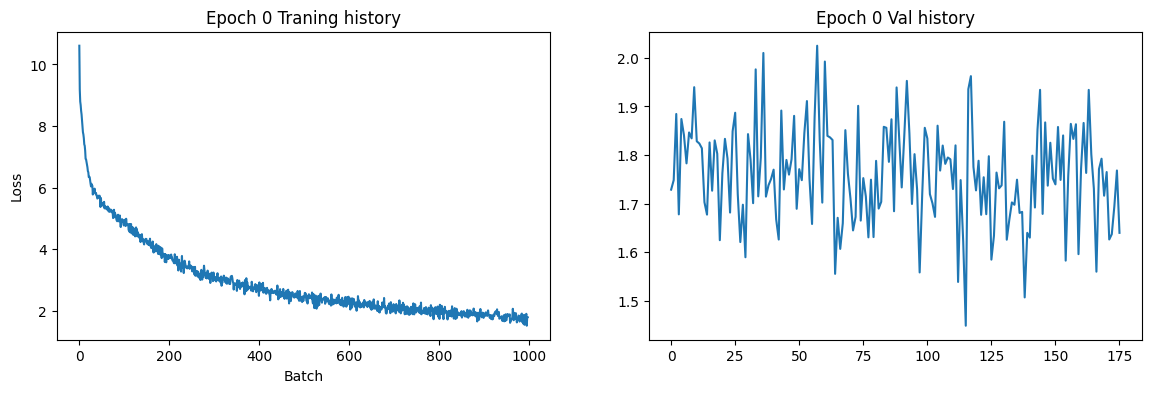

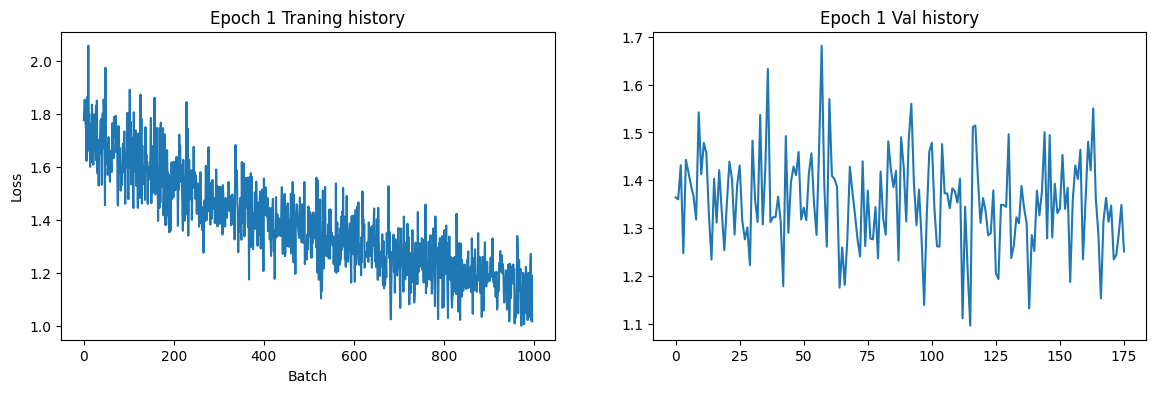

In [ ]:
import matplotlib.pyplot as plt

for epoch_data in LOSS_HISTORY_PER_EPOCH:

    e = epoch_data['epoch']
    train_history = epoch_data['train_history']
    val_history = epoch_data['val_history']

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    ax1.plot(train_history)
    ax1.set_title(f"Epoch {e} Traning history")
    ax1.set_xlabel("Batch")
    ax1.set_ylabel("Loss")

    ax2.plot(val_history)
    ax2.set_title(f"Epoch {e} Val history")
    ax1.set_xlabel("Batch")
    ax1.set_ylabel("Loss")

## Inference / Translation

In [ ]:
import random

@torch.no_grad()
def Test_model(model, x_test, y_test):

    english_sentence = []
    french_sentence = []
    model_sentence =[]

    model_prediction = None
    model.eval()

    idx = random.randint(0, X_test.shape[0])

    try:

        for ids in x_test[idx]:
            english_sentence.append(rev_english_vocab[ids])

        for ids in y_test[idx]:
            french_sentence.append(rev_french_vocab[ids])

        model_prediction = model.generate(
            torch.tensor([x_test[idx]], dtype=torch.int64, device= device), len(y_test[idx])
        )

        for ids in model_prediction:
            model_sentence.append(rev_french_vocab[ids])

    except Exception as e:
        print("Error:", e)

    finally:
        model.train()

        print("English sentence:", " ".join(english_sentence))
        print("French sentence:", " ".join(french_sentence))
        print("Model prediction:", " ".join(model_sentence))

In [18]:
Test_model(model, X_test, y_test)

English sentence: everyone is watching <eos>
French sentence: <bos> tout le monde regarde <eos>
Model prediction: <bos> tout le monde est ouvert <eos>


In [3]:
def smooth_curve(loss_history: list, alpha: float = 0.1) -> list:
    # EMA_t = alpha * loss_t + (1 - alpha) * EMA_(t-1)
    general_trend = []

    for i, loss in enumerate(loss_history):

        if i == 0:
            ema = loss
        else:
            ema = alpha * loss + (1 - alpha) * ema

        general_trend.append(ema)

    return general_trend